In [1]:
%pip install scikit-image
%pip install kagglehub
%pip install opencv-python

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.0 MB 4.5 MB/s eta 0:00:03
   ------------------------ --------------- 7.3/12.0 MB 25.2 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 33.3 MB/s  0:00:00

   ---------------------------------------- 0/4 [tifffile]
   ---------------------------------------- 0/4 [tifffile]
   -------------------- ------------------- 2/4 [imageio]
   -------------------- ------------------- 2/4 [imageio]
   -------------------- ------------------- 2/4 [imageio]
   -------------------- ------------------- 2/4 [imageio]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import cv2
from pathlib import Path

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from skimage.feature import hog
from sklearn.metrics import ConfusionMatrixDisplay


## Create DataFrames and First Data Analysis

In [3]:
test_path = Path("./data/yoga-poses/DATASET/TEST")
train_path = Path("./data/yoga-poses/DATASET/TRAIN")

In [4]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def createDF(datasetdir):
    data = {
        'image_path':[],
        'label':[]
    }
    for class_folder in datasetdir.iterdir():
        if class_folder.is_dir():
            for image_path in class_folder.iterdir():
                if image_path.suffix.lower() in IMAGE_EXTENSIONS:
                    
                    data['image_path'].append(str(image_path))
                    data['label'].append(class_folder.name)

    return data
train_data = createDF(train_path)
test_data = createDF(test_path)
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

In [5]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1080, 2)
Test shape: (470, 2)


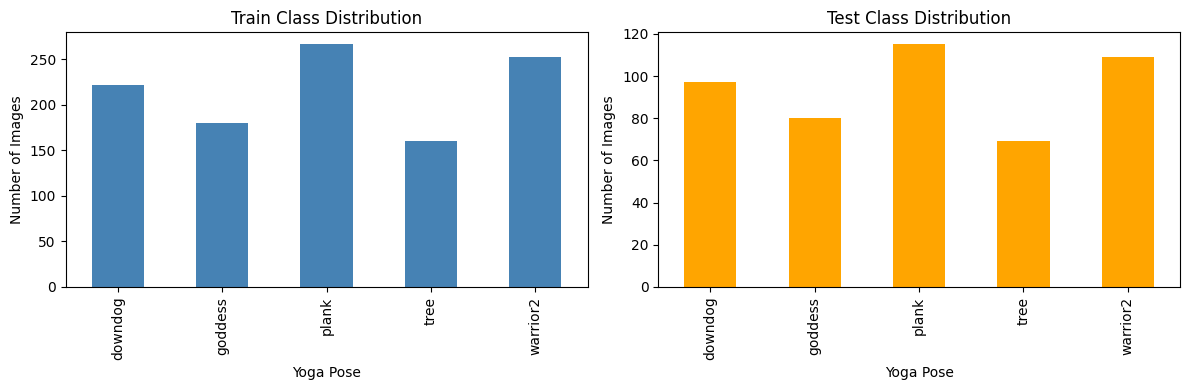

In [6]:
#Classes Classification(How many images we have in test and train sets)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_counts = train_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

train_counts.plot(
    kind="bar",
    ax=axes[0],
    color="steelblue")

test_counts.plot(
    kind="bar",
    ax=axes[1],
    color="orange")

axes[0].set_title("Train Class Distribution")
axes[0].set_xlabel("Yoga Pose")
axes[0].set_ylabel("Number of Images")

axes[1].set_title("Test Class Distribution")
axes[1].set_xlabel("Yoga Pose")
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

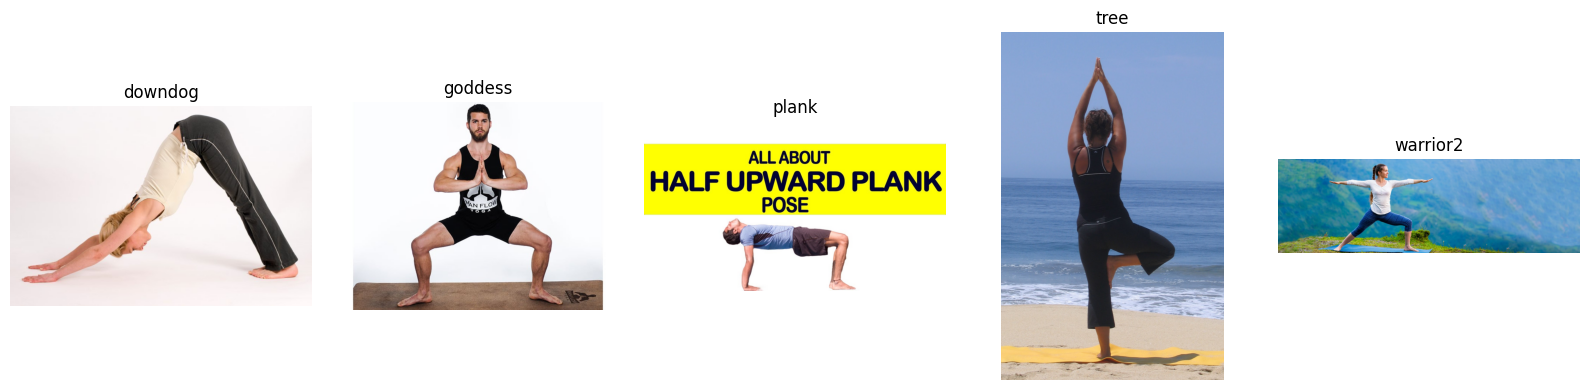

In [7]:
##Some examples from images
classes = sorted(train_df["label"].unique())

fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(16, 4))

for ax, label in zip(axes, classes):

    sample_path = train_df.loc[
        train_df["label"] == label,
        "image_path"].iloc[0]

    image = cv2.imread(sample_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image_rgb)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
#Checking size image
sample_path = train_df.loc[0, 'image_path']
sample_image = cv2.imread(sample_path)
print(sample_image.shape)

image_sizes = []
for image_path in train_df["image_path"]:
    image = cv2.imread(image_path)

    if image is not None:
        height, width = image.shape[:2]
        image_sizes.append((width, height)) 
print(image_sizes)

(564, 851, 3)
[(851, 564), (696, 463), (1200, 850), (493, 335), (1499, 706), (1280, 720), (2128, 1409), (600, 600), (760, 500), (1000, 667), (1280, 905), (999, 667), (417, 417), (640, 360), (759, 506), (1300, 876), (614, 413), (1080, 720), (1300, 957), (467, 350), (800, 600), (650, 400), (760, 450), (1280, 720), (1024, 1024), (1300, 876), (800, 600), (760, 450), (614, 413), (467, 350), (650, 400), (1280, 720), (1024, 1024), (1300, 957), (1080, 720), (865, 415), (1300, 957), (1200, 628), (640, 480), (740, 519), (740, 581), (803, 598), (700, 415), (296, 222), (480, 360), (709, 567), (1600, 600), (767, 512), (512, 512), (1280, 720), (640, 417), (570, 450), (1920, 1080), (296, 222), (408, 272), (700, 415), (1600, 600), (300, 300), (300, 186), (720, 406), (1024, 822), (1024, 651), (300, 388), (1200, 675), (1000, 496), (450, 281), (1280, 720), (760, 428), (740, 766), (1280, 720), (1024, 903), (2324, 1299), (625, 928), (1200, 1200), (750, 607), (300, 193), (3383, 1984), (3072, 2304), (1100, 6

## Feature Engennring

In [9]:
## Preprocess on image convert it to greyscale and change sizes to 64x64

IMAGE_SIZE = (64, 64)

def preprocess_image(image_path):
    image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)

    resized_image = cv2.resize(
        image,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA)

    normalized_image = resized_image.astype(np.float32) / 255.0

    return normalized_image

In [10]:
## Made gradient to image
def calculate_gradient(grey_image):
    padded_image = np.pad(
        grey_image,
        pad_width=1,
        mode="edge")

    dx = (padded_image[2:, 1:-1] - padded_image[:-2, 1:-1])

    dy = (padded_image[1:-1, 2:]- padded_image[1:-1, :-2])

    gradient = np.sqrt(dx ** 2 + dy ** 2)

    if gradient.max() > 0:
        gradient = gradient / gradient.max()

    return gradient.astype(np.float32)
    

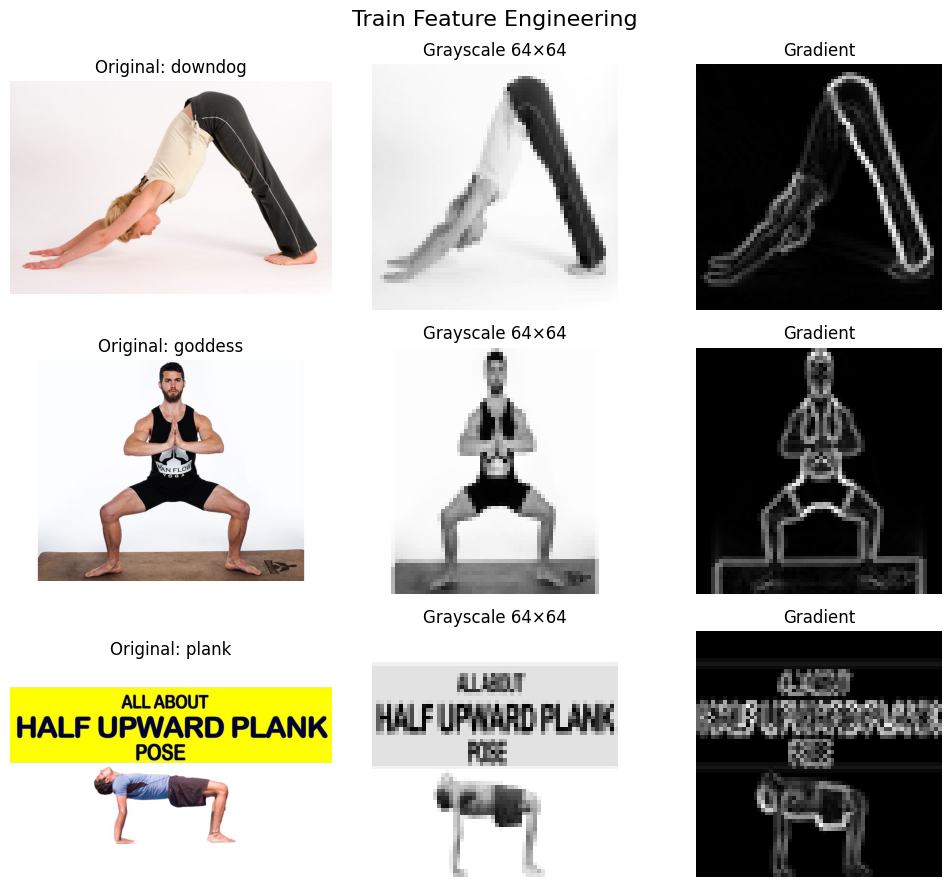

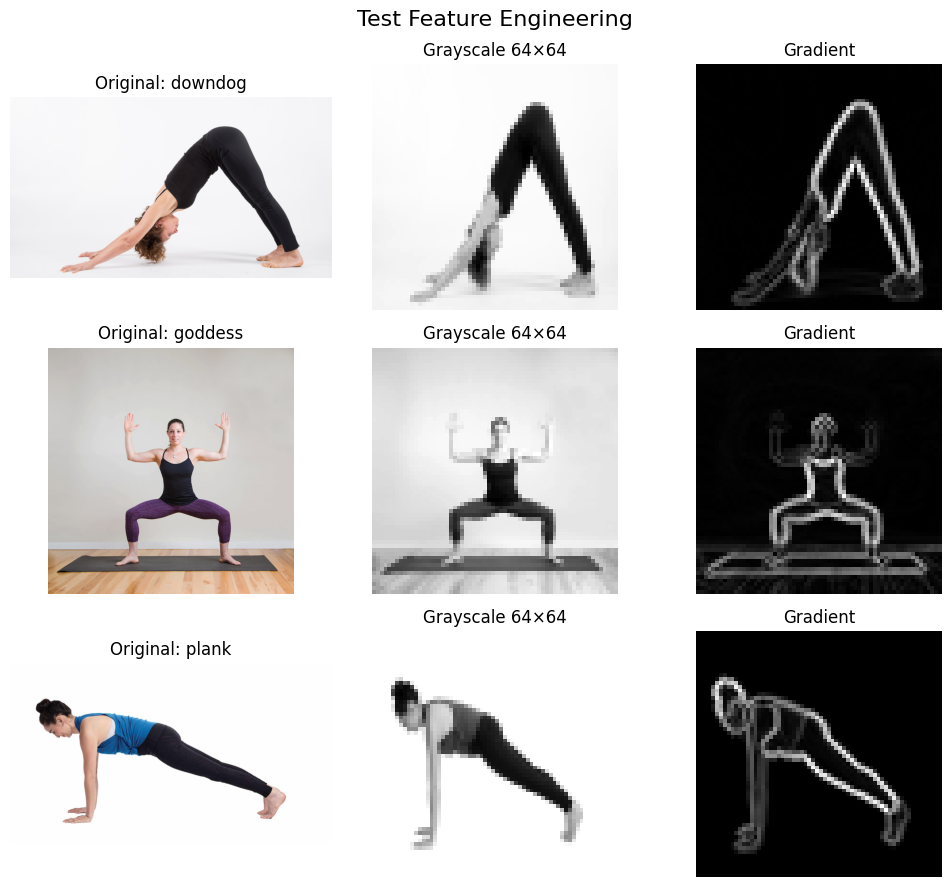

In [11]:
## Show Feature Enginnering examples
def show_gradient_examples(df, dataset_name):
    examples = (df.drop_duplicates(subset="label").head(3).reset_index(drop=True))

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 9))

    for row_index in range(3):
        image_path = examples.loc[row_index, "image_path"]
        label = examples.loc[row_index, "label"]

        original_bgr = cv2.imread(image_path)
        original_rgb = cv2.cvtColor(original_bgr,cv2.COLOR_BGR2RGB)

        processed_image = preprocess_image(image_path)
        gradient_image = calculate_gradient(processed_image)

        axes[row_index, 0].imshow(original_rgb)
        axes[row_index, 0].set_title(f"Original: {label}")

        axes[row_index, 1].imshow(processed_image,cmap="gray")
        axes[row_index, 1].set_title("Grayscale 64×64")

        axes[row_index, 2].imshow(gradient_image,cmap="gray")
        axes[row_index, 2].set_title("Gradient")

        for column_index in range(3):
            axes[row_index, column_index].axis("off")

    fig.suptitle(f"{dataset_name} Feature Engineering",fontsize=16)

    plt.tight_layout()
    plt.show()
        
show_gradient_examples(train_df, "Train")
show_gradient_examples(test_df, "Test")

In [12]:
##Create feature matrix with num_py(was prompt to AI and he advise use np.array intead of DataFrame)

def create_feature_matrices(df):
    pixel_vectors = []
    gradient_vectors = []
    labels = []

    for image_path, label in zip(df["image_path"], df["label"]):
        processed_image = preprocess_image(image_path)
        gradient_image = calculate_gradient(processed_image)

        pixel_vectors.append(processed_image.flatten())
        gradient_vectors.append(gradient_image.flatten())
        labels.append(label)

    return (
        np.array(pixel_vectors, dtype=np.float32),
        np.array(gradient_vectors, dtype=np.float32),
        np.array(labels))

X_train_pixels, X_train_gradient, y_train = (create_feature_matrices(train_df))

In [17]:
print(X_train_pixels.shape)
print(X_train_gradient.shape)
print(y_train.shape)

(1080, 4096)
(1080, 4096)
(1080,)


In [26]:
#Bonus Calculating HOG(Also AI prompt)
def calculate_hog(image, pixels_per_cell):
    hog_features, hog_image = hog(image, orientations=9, pixels_per_cell=pixels_per_cell, cells_per_block=(2, 2), block_norm="L2-Hys", visualize=True, feature_vector=True)

    return (hog_features.astype(np.float32), hog_image)


In [27]:
#Checking HOG on one Image, HOG create less feture 
sample_path = train_df.loc[0, "image_path"]
sample_image = preprocess_image(sample_path)

hog_features, hog_image = calculate_hog(sample_image, pixels_per_cell=(8, 8))

print("Input image shape:", sample_image.shape)
print("HOG vector shape:", hog_features.shape)

Input image shape: (64, 64)
HOG vector shape: (1764,)


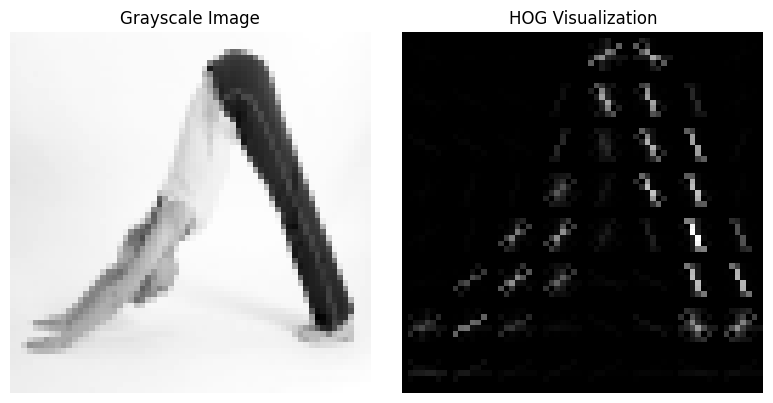

In [28]:
##Visualization
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(sample_image, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")

axes[1].imshow(hog_image, cmap="gray")
axes[1].set_title("HOG Visualization")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [31]:
#Create 2 hog features one 8x8 and 16x16

def create_hog_matrix(df, pixels_per_cell):
    hog_vectors = []

    for image_path in df["image_path"]:
        image = preprocess_image(image_path)

        hog_features, _ = calculate_hog(image, pixels_per_cell=pixels_per_cell)

        hog_vectors.append(hog_features)

    return np.array(hog_vectors, dtype=np.float32)

X_train_hog_8 = create_hog_matrix(train_df, pixels_per_cell=(8, 8))

X_train_hog_16 = create_hog_matrix(train_df,pixels_per_cell=(16, 16))

In [32]:
print("HOG 8×8:", X_train_hog_8.shape)
print("HOG 16×16:", X_train_hog_16.shape)
print("Labels:", y_train.shape)

HOG 8×8: (1080, 1764)
HOG 16×16: (1080, 324)
Labels: (1080,)


## Baseline KNN

In [33]:
feature_sets = {
    "pixels": X_train_pixels,
    "gradient": X_train_gradient,
    "hog_8x8": X_train_hog_8,
    "hog_16x16": X_train_hog_16}

for name, X in feature_sets.items():
    print(name, X.shape)

pixels (1080, 4096)
gradient (1080, 4096)
hog_8x8 (1080, 1764)
hog_16x16 (1080, 324)


In [39]:
##Traning model KNN
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

max_k = int(np.sqrt(len(y_train)))

k_values = list(range(1, max_k + 1, 2))

knn_parameters = {
    "n_neighbors": k_values,
    "weights": ["uniform", "distance"]}

knn_results_list =[]

for feature_name, X_train in feature_sets.items():

    knn = KNeighborsClassifier()

    grid_search = GridSearchCV(estimator=knn, param_grid=knn_parameters, scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True)

    grid_search.fit(X_train, y_train)

    current_results = pd.DataFrame(grid_search.cv_results_)

    current_results["feature_set"] = feature_name

    knn_results_list.append(current_results[["feature_set", "param_n_neighbors", "param_weights", "mean_train_score", "mean_test_score", "std_test_score" ]])

knn_results = pd.concat( knn_results_list, ignore_index=True)
knn_results = knn_results.sort_values(by="mean_test_score", ascending=False)
best_knn_result = knn_results.iloc[0]
best_knn_result

feature_set          hog_16x16
param_n_neighbors           15
param_weights         distance
mean_train_score      0.999046
mean_test_score       0.775736
std_test_score        0.022877
Name: 111, dtype: object

In [40]:
best_indexes = knn_results.groupby("feature_set")["mean_test_score"].idxmax()

knn_best_by_feature = (knn_results.loc[best_indexes].sort_values("mean_test_score", ascending=False).reset_index(drop=True))

knn_best_by_feature

,feature_set,param_n_neighbors,param_weights,mean_train_score,mean_test_score,std_test_score
0,hog_16x16,15,distance,0.999046,0.775736,0.022877
1,hog_8x8,21,distance,0.999046,0.769393,0.037362
2,gradient,1,uniform,0.998336,0.617595,0.020265
3,pixels,1,uniform,0.998336,0.588607,0.031037


## Complex Model SVM Kernel

In [47]:
svm_parameters = [
       {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", 0.001, 0.01, 0.1]
    }
]


In [49]:
svm_results_list = []

for feature_name, X_features in feature_sets.items():

    svm = SVC()

    grid_search = GridSearchCV(estimator=svm, param_grid=svm_parameters, scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True)

    grid_search.fit(X_features, y_train)

    current_results = pd.DataFrame(grid_search.cv_results_)

    current_results["feature_set"] = feature_name

    svm_results_list.append(
        current_results[
            [
            "feature_set",
            "param_kernel",
            "param_C",
            "param_gamma",
            "mean_train_score",
            "mean_test_score",
            "std_test_score"
            ]
        ]
    )

In [50]:
svm_results = pd.concat(svm_results_list, ignore_index=True)

svm_results["overfitting_gap"] = (svm_results["mean_train_score"]- svm_results["mean_test_score"])

svm_results = svm_results.sort_values(by="mean_test_score",ascending=False).reset_index(drop=True)

svm_results

,feature_set,param_kernel,param_C,param_gamma,mean_train_score,mean_test_score,std_test_score,overfitting_gap
0,hog_8x8,rbf,10.0,scale,0.999046,0.812322,0.033997,1.867249e-01
1,hog_8x8,rbf,100.0,scale,0.999046,0.812322,0.033997,1.867249e-01
2,hog_8x8,rbf,1.0,scale,0.968367,0.800936,0.034332,1.674301e-01
3,hog_8x8,rbf,100.0,0.01,0.999046,0.795948,0.038490,2.030989e-01
4,hog_8x8,rbf,10.0,0.01,0.998571,0.794604,0.036518,2.039667e-01
...,...,...,...,...,...,...,...,...
75,gradient,rbf,0.1,0.001,0.079049,0.079048,0.000476,6.627248e-07
76,hog_8x8,rbf,0.1,0.1,0.079049,0.079048,0.000476,6.627248e-07
77,hog_16x16,rbf,1.0,0.001,0.079049,0.079048,0.000476,6.627248e-07
78,hog_16x16,rbf,0.1,0.001,0.079049,0.079048,0.000476,6.627248e-07


In [51]:
best_svm_result = svm_results.iloc[0]

best_svm_result

feature_set          hog_8x8
param_kernel             rbf
param_C                 10.0
param_gamma            scale
mean_train_score    0.999046
mean_test_score     0.812322
std_test_score      0.033997
overfitting_gap     0.186725
Name: 0, dtype: object

In [52]:
best_indexes = svm_results.groupby("feature_set")["mean_test_score"].idxmax()

svm_best_by_feature = (svm_results.loc[best_indexes].sort_values("mean_test_score", ascending=False).reset_index(drop=True))

svm_best_by_feature

,feature_set,param_kernel,param_C,param_gamma,mean_train_score,mean_test_score,std_test_score,overfitting_gap
0,hog_8x8,rbf,10.0,scale,0.999046,0.812322,0.033997,0.186725
1,hog_16x16,rbf,100.0,scale,0.999046,0.789833,0.019322,0.209213
2,gradient,rbf,100.0,scale,0.999047,0.710948,0.034067,0.288099
3,pixels,rbf,10.0,scale,0.998096,0.672232,0.033079,0.325863


In [53]:
model_comparison = pd.DataFrame([
    {
        "model": "KNN",
        "feature_set": best_knn_result["feature_set"],
        "parameters": (
            f"k={best_knn_result['param_n_neighbors']}, "
            f"weights={best_knn_result['param_weights']}"
        ),
        "cv_macro_f1": best_knn_result["mean_test_score"],
        "std_cv": best_knn_result["std_test_score"]
    },
    {
        "model": "SVM",
        "feature_set": best_svm_result["feature_set"],
        "parameters": (
            f"kernel={best_svm_result['param_kernel']}, "
            f"C={best_svm_result['param_C']}, "
            f"gamma={best_svm_result['param_gamma']}"
        ),
        "cv_macro_f1": best_svm_result["mean_test_score"],
        "std_cv": best_svm_result["std_test_score"]
    }
])

model_comparison.sort_values("cv_macro_f1",ascending=False).reset_index(drop=True)

,model,feature_set,parameters,cv_macro_f1,std_cv
0,SVM,hog_8x8,"kernel=rbf, C=10.0, gamma=scale",0.812322,0.033997
1,KNN,hog_16x16,"k=15, weights=distance",0.775736,0.022877


In [54]:
##Try to upgrade f1 score in SVM

refined_parameters = {
    "kernel": ["rbf"],
    "C": [1, 3, 5, 10, 20, 50, 100],
    "gamma": [
        "scale",
        0.005,
        0.01,
        0.02,
        0.05,
        0.1]}

refined_search = GridSearchCV(estimator=SVC(),param_grid=refined_parameters,scoring="f1_macro",cv=cv,n_jobs=-1, return_train_score=True)

refined_search.fit(X_train_hog_8, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 3, ...], 'gamma': ['scale', 0.005, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [55]:
print("Best parameters:", refined_search.best_params_)
print("Best CV Macro F1:", refined_search.best_score_)

Best parameters: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Macro F1: 0.8123215764961232


In [56]:
old_score = float(best_svm_result["mean_test_score"])
new_score = refined_search.best_score_

print("Old CV Macro F1:", old_score)
print("New CV Macro F1:", new_score)
print("Improvement:", new_score - old_score)

Old CV Macro F1: 0.8123215764961232
New CV Macro F1: 0.8123215764961232
Improvement: 0.0


## Final Test of best models

In [59]:
y_test = test_df["label"].to_numpy()

X_test_hog_8 = create_hog_matrix(test_df,pixels_per_cell=(8, 8))

X_test_hog_16 = create_hog_matrix(test_df,pixels_per_cell=(16, 16))

print("HOG 8×8:", X_test_hog_8.shape)
print("HOG 16×16:", X_test_hog_16.shape)
print("Labels:", y_test.shape)

HOG 8×8: (470, 1764)
HOG 16×16: (470, 324)
Labels: (470,)


In [60]:
assert len(X_test_hog_8) == len(y_test)
assert len(X_test_hog_16) == len(y_test)

print("Test matrices are correct")

Test matrices are correct


In [62]:
#Final models with best parametrs
final_knn = KNeighborsClassifier(n_neighbors=15,weights="distance")
final_svm = SVC(kernel="rbf",C=5, gamma="scale")

In [63]:
final_knn.fit(X_train_hog_16,y_train)
final_svm.fit(X_train_hog_8,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [64]:
y_pred_knn = final_knn.predict(X_test_hog_16)

y_pred_svm = final_svm.predict( X_test_hog_8)

In [66]:
test_results = pd.DataFrame([
    {   "model": "KNN",
        "feature_set": "HOG 16×16",
        "accuracy": accuracy_score(y_test, y_pred_knn),
        "macro_f1": f1_score(y_test,y_pred_knn,average="macro")
    },
    {
        "model": "SVM",
        "feature_set": "HOG 8×8",
        "accuracy": accuracy_score(y_test, y_pred_svm),
        "macro_f1": f1_score(y_test,y_pred_svm,average="macro")
    }
])

test_results = test_results.sort_values("macro_f1",ascending=False).reset_index(drop=True)

test_results

,model,feature_set,accuracy,macro_f1
0,SVM,HOG 8×8,0.908511,0.911383
1,KNN,HOG 16×16,0.853191,0.855631


In [67]:
prediction_examples = pd.DataFrame({
    "image_path": test_df["image_path"].values,
    "true_label": y_test,
    "knn_prediction": y_pred_knn,
    "svm_prediction": y_pred_svm})

prediction_examples["knn_correct"] = (
    prediction_examples["true_label"]
    == prediction_examples["knn_prediction"])

prediction_examples["svm_correct"] = (
    prediction_examples["true_label"]
    == prediction_examples["svm_prediction"])

prediction_examples.head(5)

,image_path,true_label,knn_prediction,svm_prediction,knn_correct,svm_correct
0,data\yoga-poses\DATASET\TEST\downdog\00000000.jpg,downdog,downdog,downdog,True,True
1,data\yoga-poses\DATASET\TEST\downdog\00000001.JPG,downdog,downdog,downdog,True,True
2,data\yoga-poses\DATASET\TEST\downdog\00000002.jpg,downdog,downdog,downdog,True,True
3,data\yoga-poses\DATASET\TEST\downdog\00000003.jpg,downdog,downdog,downdog,True,True
4,data\yoga-poses\DATASET\TEST\downdog\00000004.jpg,downdog,downdog,downdog,True,True


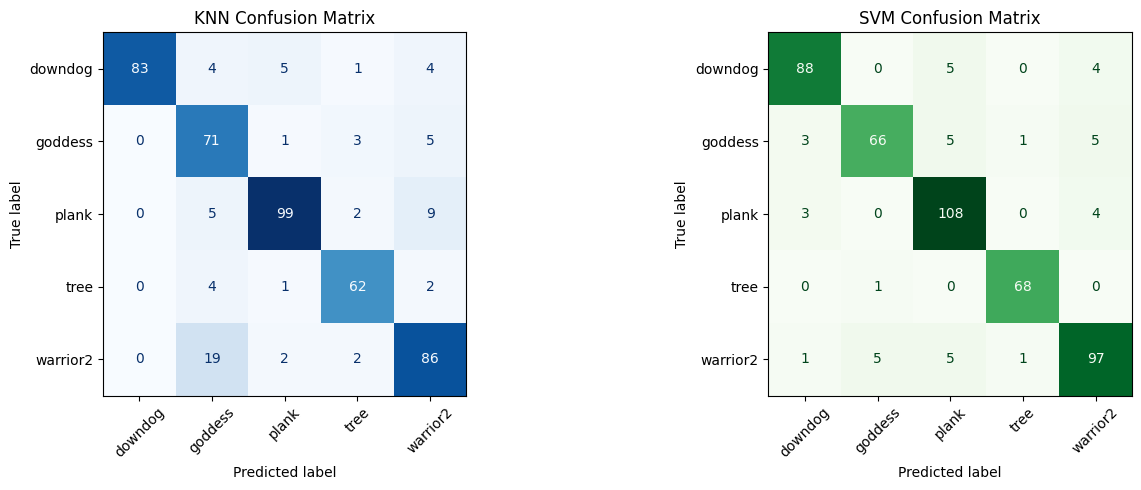

In [70]:
#Confusion Matrix(AI help)

class_names = np.unique(y_test)

fig, axes = plt.subplots(1,2,figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn,labels=class_names,display_labels=class_names,cmap="Blues",xticks_rotation=45,colorbar=False,ax=axes[0])

axes[0].set_title("KNN Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_svm,labels=class_names,display_labels=class_names,cmap="Greens",xticks_rotation=45,colorbar=False,ax=axes[1])

axes[1].set_title("SVM Confusion Matrix")

plt.tight_layout()
plt.show()